In [1]:
# Loading Enviroment 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Loading dataset
df = pd.read_csv('/kaggle/input/datasets/chaitanyajamble/global-e-commerce-user-behavior-and-conversion-data/ecommerce_user_behavior_sessions.csv')

In [3]:
# Basic Stats and Info
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   session_id               2500 non-null   int64  
 1   visit_date               2500 non-null   object 
 2   country                  2500 non-null   object 
 3   device_type              2500 non-null   object 
 4   traffic_source           2500 non-null   object 
 5   product_category_viewed  2500 non-null   object 
 6   pages_viewed             2500 non-null   int64  
 7   time_on_site_minutes     2500 non-null   float64
 8   added_to_cart            2500 non-null   int64  
 9   purchased                2500 non-null   int64  
 10  order_value_usd          2500 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 215.0+ KB
None
       session_id  pages_viewed  time_on_site_minutes  added_to_cart  \
count  2500.00000   2500.000000           2500.000

In [4]:
df['visit_date'] = pd.to_datetime(df['visit_date'])

In [5]:
print(df['visit_date'].dtype)

datetime64[ns]


In [6]:
# Checking for missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 session_id                 0
visit_date                 0
country                    0
device_type                0
traffic_source             0
product_category_viewed    0
pages_viewed               0
time_on_site_minutes       0
added_to_cart              0
purchased                  0
order_value_usd            0
dtype: int64


In [7]:
# Data type and categorical analysis
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

Categorical Columns: Index(['country', 'device_type', 'traffic_source', 'product_category_viewed'], dtype='object')


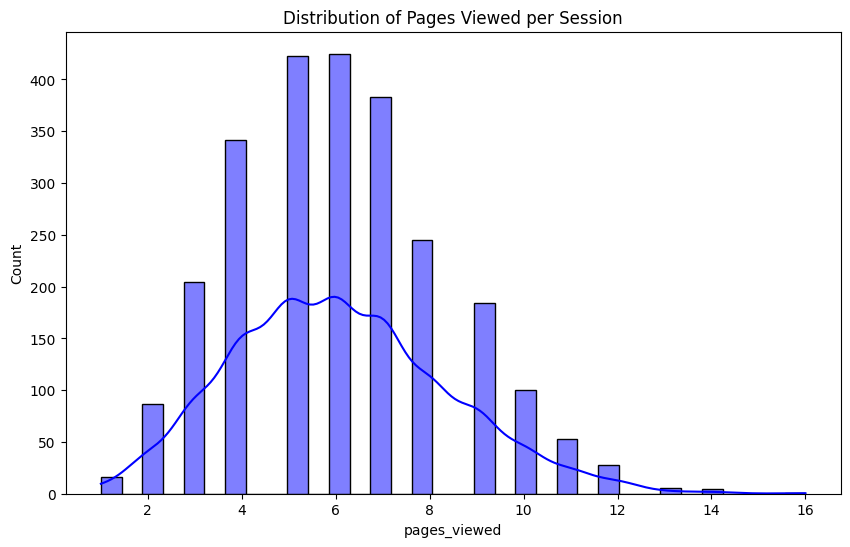

In [8]:
# Univariate Analysis: Distribution of Pages Viewed
plt.figure(figsize=(10, 6))
sns.histplot(df['pages_viewed'], kde=True, color='blue')
plt.title('Distribution of Pages Viewed per Session')
plt.show()

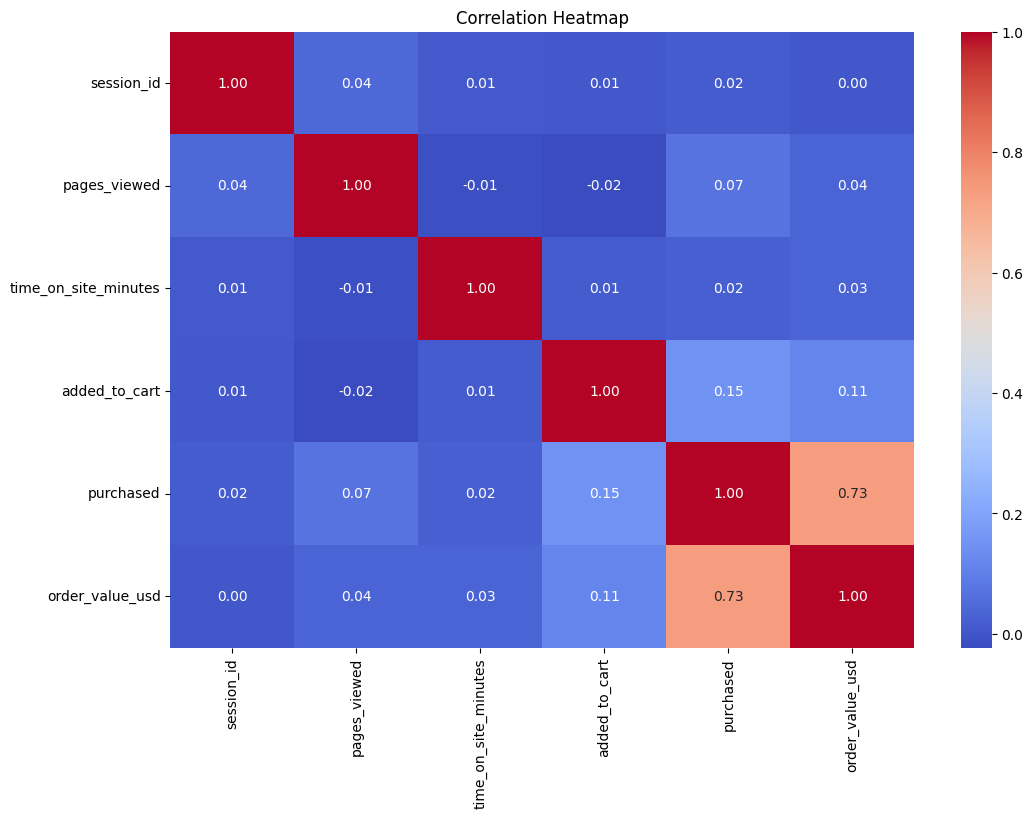

In [9]:
# Correlation Analysis
# We convert categorical to codes temporarily for a quick correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

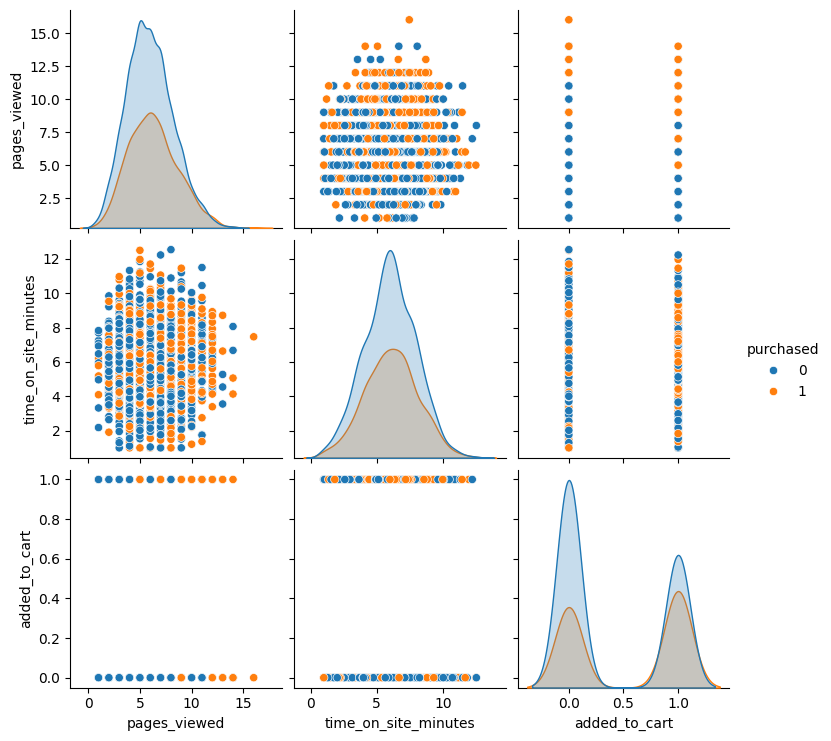

In [10]:
# Pair plots and Joint plots
sns.pairplot(df, hue='purchased', vars=['pages_viewed', 'time_on_site_minutes', 'added_to_cart'])
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cols = ['country', 'device_type', 'traffic_source', 'product_category_viewed']

for col in cols:
    df[col] = le.fit_transform(df[col])

df[cols].head(2)

,country,device_type,traffic_source,product_category_viewed
0,0,1,2,1
1,4,1,3,3


In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Recreating the column
df['cart_to_view_ratio'] = df['added_to_cart'] / (df['pages_viewed'] + 1)

# 2. Defining X and y
X = df[['pages_viewed', 'time_on_site_minutes', 'added_to_cart', 'cart_to_view_ratio']]
y = df['purchased']

# 3. Training the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 4. Showing Results
print("Success! Feature Importance Scores:")
importances = dict(zip(X.columns, model.feature_importances_))
for feature, score in importances.items():
    print(f"{feature}: {score:.4f}")

Success! Feature Importance Scores:
pages_viewed: 0.0675
time_on_site_minutes: 0.8863
added_to_cart: 0.0117
cart_to_view_ratio: 0.0345


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Preparing the data
X = df.drop(['session_id', 'visit_date', 'purchased'], axis=1)
y = df['purchased']

# Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initializing and Fitting the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predictions and Evaluation
y_pred = model.predict(X_test)

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

--- CONFUSION MATRIX ---
[[306   0]
 [  0 194]]

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       194

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



In [16]:
# Remove the "Cheating" column (order_value_usd)
X_realistic = df.drop(['session_id', 'visit_date', 'purchased', 'order_value_usd'], axis=1)
y = df['purchased']

# Re-split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_realistic, y, test_size=0.2, random_state=42)

# Re-train
model_realistic = RandomForestClassifier(n_estimators=100, random_state=42)
model_realistic.fit(X_train_r, y_train_r)

# Re-evaluate
y_pred_r = model_realistic.predict(X_test_r)
print("--- REALISTIC RESULTS ---")
print(classification_report(y_test_r, y_pred_r))

--- REALISTIC RESULTS ---
              precision    recall  f1-score   support

           0       0.63      0.80      0.71       306
           1       0.46      0.27      0.34       194

    accuracy                           0.60       500
   macro avg       0.55      0.54      0.53       500
weighted avg       0.57      0.60      0.57       500



In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Creating a "Synthetic Satisfaction Score" (0 to 10 scale)
# Logic: Users who spend more time AND buy are 'Satisfied'
df['satisfaction_score'] = ((df['time_on_site_minutes'] / df['time_on_site_minutes'].max() * 5) + 
                            (df['purchased'] * 5))

# Predicting "Session Value" (CLV)
# We use the mean order value as a baseline for active sessions
df['predicted_session_value'] = df['pages_viewed'] * (df['order_value_usd'].mean() / df['pages_viewed'].mean())

# K-Means Customer Segmentation
# We use behavior (Time) and value (Order Value) to group users
features = ['time_on_site_minutes', 'order_value_usd', 'satisfaction_score']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=3, random_state=42)
df['customer_segment'] = kmeans.fit_predict(scaled_features)

# 4. Final Summary of Segments
segment_summary = df.groupby('customer_segment')[['time_on_site_minutes', 'order_value_usd', 'satisfaction_score']].mean()
print("--- FINAL CUSTOMER SEGMENTATION ---")
print(segment_summary)

--- FINAL CUSTOMER SEGMENTATION ---
                  time_on_site_minutes  order_value_usd  satisfaction_score
customer_segment                                                           
0                             4.209827         1.613081            1.938863
1                             6.258380        81.165028            7.497358
2                             7.398030         0.000000            2.952127


In [18]:
# Identifying the 'Churn Risk' sessions
churn_risk_df = df[(df['time_on_site_minutes'] > df['time_on_site_minutes'].mean()) & (df['purchased'] == 0)]

# The most common product category these users looked at
print(f"Total Churn Risk Users: {len(churn_risk_df)}")
print("\nTop Categories where users browse but don't buy:")
print(churn_risk_df['product_category_viewed'].value_counts().head())

# The average 'Satisfaction Score' for these specific users
print(f"\nAverage Satisfaction for Churn Risk: {churn_risk_df['satisfaction_score'].mean():.2f}")

Total Churn Risk Users: 777

Top Categories where users browse but don't buy:
product_category_viewed
4    143
3    136
1    129
2    125
5    122
Name: count, dtype: int64

Average Satisfaction for Churn Risk: 3.01


# Project Executive Summary: E-Commerce Behavioral Analysis

---

### Key Discovery
**Behavioral "Time on Site"** is the strongest predictor of intent with an **88.6% importance score**, signaling that engagement depth is more critical than raw page views. However, high engagement does not always guarantee conversion.

---

### Customer Segmentation
Using **K-Means Clustering**, I identified three distinct user personas based on their browsing and spending habits:

* **Segment 0 (Bouncers):** Low engagement and low value, averaging only **$1.61** in spend.
* **Segment 1 (MVPs):** High-efficiency shoppers providing the highest ROI with an average spend of **$81.16**.
* **Segment 2 (Window Shoppers):** These users spent the **longest time on site** but resulted in **zero conversion**, representing a major untapped opportunity.

---

### Actionable Insight
My analysis identified **777 users (31% of total traffic)** who are "High-Intent" but churned before checkout. 

> **Recommendation:** Implementing targeted interventions, such as exit-intent discount pop-ups specifically in **Product Category 4**, could recover significant lost revenue by nudging these high-engagement "Window Shoppers" toward a purchase.